In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn scikit-fuzzy pgmpy

In [2]:
!pip install pandas


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

import skfuzzy as fuzz
import skfuzzy.control as ctrl

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator


C:\Users\hp\.conda\envs\traffic_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Sample dataset: Real data should come from traffic records
data = pd.DataFrame({
    'Speed': np.random.randint(40, 121, 100),
    'Distance': np.random.randint(5, 50, 100),
    'Weather': np.random.choice(['Clear', 'Rainy', 'Foggy'], 100),
    'Road_Condition': np.random.choice(['Dry', 'Wet', 'Snowy'], 100),
    'Driver_Behavior': np.random.choice(['Calm', 'Aggressive'], 100),
    'Accident': np.random.choice(['Yes', 'No'], 100)
})
data.head()


,Speed,Distance,Weather,Road_Condition,Driver_Behavior,Accident
0,111,38,Foggy,Dry,Calm,No
1,76,31,Clear,Snowy,Calm,Yes
2,79,9,Foggy,Dry,Calm,No
3,87,46,Foggy,Wet,Aggressive,No
4,105,48,Foggy,Dry,Aggressive,Yes


In [5]:
df_encoded = data.copy()
df_encoded['Weather'] = df_encoded['Weather'].map({'Clear': 0, 'Rainy': 1, 'Foggy': 2})
df_encoded['Road_Condition'] = df_encoded['Road_Condition'].map({'Dry': 0, 'Wet': 1, 'Snowy': 2})
df_encoded['Driver_Behavior'] = df_encoded['Driver_Behavior'].map({'Calm': 0, 'Aggressive': 1})
df_encoded['Accident'] = df_encoded['Accident'].map({'No': 0, 'Yes': 1})
df_encoded.rename(columns={
    'Speed': 'speed',
    'Distance': 'distance',
    'Weather': 'weather',
    'Road_Condition': 'road',
    'Driver_Behavior': 'driver',
    'Accident': 'accident'
}, inplace=True)
df_encoded.head()

,speed,distance,weather,road,driver,accident
0,111,38,2,0,0,0
1,76,31,0,2,0,1
2,79,9,2,0,0,0
3,87,46,2,1,1,0
4,105,48,2,0,1,1


In [6]:
model_bbn = DiscreteBayesianNetwork([
    ('weather', 'accident'),
    ('road', 'accident'),
    ('driver', 'accident'),
    ('speed', 'accident'),
    ('distance', 'accident')
])

model_bbn.fit(df_encoded, estimator=MaximumLikelihoodEstimator)
print("BBN Training Completed ✅")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'speed': 'N', 'distance': 'N', 'weather': 'N', 'road': 'N', 'driver': 'N', 'accident': 'N'}


BBN Training Completed ✅


In [7]:
speed = ctrl.Antecedent(np.arange(0, 151, 1), 'speed')
distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
risk = ctrl.Consequent(np.arange(0, 101, 1), 'risk')

speed['poor'] = fuzz.trimf(speed.universe, [0, 0, 60])
speed['average'] = fuzz.trimf(speed.universe, [40, 80, 120])
speed['good'] = fuzz.trimf(speed.universe, [100, 150, 150])

distance['poor'] = fuzz.trimf(distance.universe, [0, 0, 20])
distance['average'] = fuzz.trimf(distance.universe, [10, 25, 40])
distance['good'] = fuzz.trimf(distance.universe, [30, 50, 50])

risk['poor'] = fuzz.trimf(risk.universe, [0, 0, 40])
risk['average'] = fuzz.trimf(risk.universe, [30, 50, 70])
risk['good'] = fuzz.trimf(risk.universe, [60, 100, 100])

rule1 = ctrl.Rule(speed['poor'] & distance['good'], risk['good'])
rule2 = ctrl.Rule(speed['average'] & distance['average'], risk['average'])
rule3 = ctrl.Rule(speed['good'] & distance['poor'], risk['poor'])

risk_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
risk_simulation = ctrl.ControlSystemSimulation(risk_ctrl)

risk_simulation.input['speed'] = 100
risk_simulation.input['distance'] = 10
risk_simulation.compute()

try:
    risk_simulation.compute()
    print("Fuzzy Risk Output:", risk_simulation.output['risk'])
except Exception as e:
    print("❌ Error:", e)
    print("Output keys:", risk_simulation.output.keys())

❌ Error: 'risk'
Output keys: dict_keys([])


C:\Users\hp\.conda\envs\traffic_env\lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


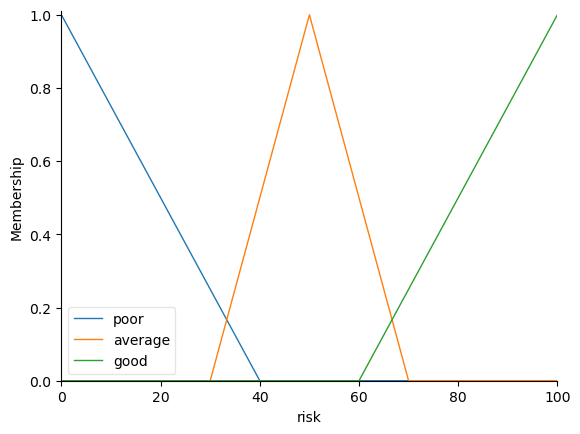

In [8]:
# Visualize
risk.view(sim=risk_simulation)